In [65]:
# Verify we hold the correct file context
print("File context verified.")

File context verified.


In [66]:
%pip install gensim
%pip install imbalanced-learn
%pip install pandas
%pip install openai python-dotenv
%pip install graphviz

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
import pandas as pd
df = pd.read_csv("cleaned_file.csv", on_bad_lines='skip')

df.head()

,payload,classification
0,sullivanjj@state.gov,high
1,"Koh, Harold Hongju",high
2,"Dear customer, you have 16,590 points which will expire on 02/05/2025 Please redeem your present immediately! Pleaseclick:http://globe-points-ph.one/ph Redeem your present!",low
3,mark.guzman@enron.com,high
4,"icd_code=0090, icd_version=9, diagnosis=Infectious colitis, enteritis, and gastroenteritis",high


In [68]:
df = df.rename(columns={
    df.columns[0]: 'Tag',
    df.columns[1]: 'Sensitivity'
})

df['Sensitivity'] = (
    df['Sensitivity']
        .astype(str)          # ensure string
        .str.strip()          # remove spaces
        .str.capitalize()     # High / Low format
)




In [69]:
print(df['Sensitivity'].value_counts())

Sensitivity
High    5876
Low     4425
Name: count, dtype: int64


In [70]:
print(df['Sensitivity'].unique())
print(df['Tag'].nunique())


['High' 'Low']
9393


In [71]:
df = df.dropna(subset=['Sensitivity'])
df = df.drop_duplicates(subset='Tag', keep=False)

df.shape[0]

print(df['Sensitivity'].unique())
print(df['Tag'].nunique())


['High' 'Low']
9006


In [72]:
import re
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[=;:/\\._,\]\'"{}#%!<>$+()&-]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if not re.search(r'\d', t)]  # remove tokens with numbers
    tokens = [t for t in tokens if not re.search(r'^[a-f0-9:,]+$', t)]  # remove hex/timestamp tokens

    text = ' '.join(tokens)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [73]:
from sklearn.model_selection import train_test_split

X = df['Tag']
y = df['Sensitivity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (7204,)
Shape of X_test: (1802,)
Shape of y_train: (7204,)
Shape of y_test: (1802,)


In [74]:
print(X_train)

2036                                  UPS: Your package requires teriyaki sauce appraisal. Provide: http://ups-teriyaki-sauce-appraisal-5567.teriyaki
9792                                                                                    cfips=13179; name=Liberty; long=-81.49463778; lat=31.82777126
5056                                                    icd_code: G35, icd_version: 10, diagnosis: Multiple sclerosis, relapsing-remitting, EDSS: 2.5
8586                                           icd_code=Z31.63, icd_version=10, diagnosis=Encounter for genetic counseling for fertility preservation
1435                                                                  Your Twitter Circle new members. Welcome: http://twitter-circle-new-5567.circle
                                                                            ...                                                                      
589                                                          UPS: Your package requires age verifica

In [75]:
#X_train_sample = X_train.apply(preprocess_text)
#print (X_train_sample)

In [76]:
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.preprocessing import FunctionTransformer
from imblearn.over_sampling import SMOTE

def whitespace_at_tokenizer(text):
    text = text.lower()
    tokens = re.split(r'(\@)', text)
    result = []
    for part in tokens:
        if part == '@':
            result.append(part)
        else:
            result += part.split()
    return [t for t in result if t.strip()]

count_vectorizer = CountVectorizer(
    analyzer='word',
    token_pattern=r"(?u)\b\w{2,}\b|@",
    ngram_range=(2,3),
    max_features=5000,
    min_df=2,
    preprocessor=preprocess_text,
    stop_words='english'
)

X_vectorized = count_vectorizer.fit_transform(df['Tag'])

smote = SMOTE(random_state=42) 
X_resampled, y_resampled = smote.fit_resample(X_vectorized, df['Sensitivity'])

print(pd.Series(y_resampled).value_counts())

Sensitivity
High    4875
Low     4875
Name: count, dtype: int64


In [99]:
import numpy as np
import pandas as pd
import re

sample_df = df[['Tag', 'Sensitivity']].sample(10, random_state=42).reset_index(drop=True)

def whitespace_at_tokenizer(text):
    text = text.lower()
    tokens = re.split(r'(\@)', text)
    result = []
    for part in tokens:
        if part == '@':
            result.append(part)
        else:
            result += part.split()
    return [t for t in result if t.strip()]

def show_word_tokens(text):
    tokens = whitespace_at_tokenizer(text)
    result = []
    # unigrams
    result += tokens
    # bigrams
    result += [f'{tokens[i]} {tokens[i+1]}' for i in range(len(tokens) - 1)]
    return result

sample_vectorizer = CountVectorizer(
    analyzer='word',
    token_pattern=r"(?u)\b\w{2,}\b|@",
    ngram_range=(2, 3),
    max_features=5000,
    min_df=1,
    preprocessor=preprocess_text,
    stop_words='english'
)

sample_df['Tag_Preprocessed'] = sample_df['Tag'].apply(preprocess_text)

sample_vectorizer.fit(sample_df['Tag'])

sample_df['Word_Tokenized'] = sample_df['Tag_Preprocessed'].apply(show_word_tokens)

sample_df['Word_Vectorized'] = sample_df['Tag'].apply(
    lambda x: sample_vectorizer.transform([x]).toarray()[0]
)

pd.set_option('display.max_colwidth', None)
sample_df[['Tag', 'Sensitivity', 'Word_Tokenized', 'Word_Vectorized']]

,Tag,Sensitivity,Word_Tokenized,Word_Vectorized
0,cfips=01119;name=Sumter;Longitude=-88.19904039;Latitude=32.59104949;,Low,"[cfips, name, sumter, longitude, latitude, cfips name, name sumter, sumter longitude, longitude latitude]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]"
1,"patient_record: MRN: 99127, diagnosis: Multiple sclerosis, relapsing-remitting, EDSS: 2.5, last_relapse: 2025-12-10 (optic neuritis), DMT: Ocrelizumab 600mg IV q6 months, last_infusion: 2026-01-15, next_infusion: 2026-07-15, MRI_burden: Stable, no new T2 lesions, MRN: 99127",High,"[patient, record, mrn, diagnosis, multiple, sclerosis, relapsing, remitting, edss, last, relapse, optic, neuritis, dmt, ocrelizumab, iv, months, last, infusion, next, infusion, mri, burden, stable, no, new, lesions, mrn, patient record, record mrn, mrn diagnosis, diagnosis multiple, multiple sclerosis, sclerosis relapsing, relapsing remitting, remitting edss, edss last, last relapse, relapse optic, optic neuritis, neuritis dmt, dmt ocrelizumab, ocrelizumab iv, iv months, months last, last infusion, infusion next, next infusion, infusion mri, mri burden, burden stable, stable no, no new, new lesions, lesions mrn]","[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...]"
2,"$9,500 Seychelles Private Island Giveaway! Enter: http://seychelles-island-giveaway.com",Low,"[seychelles, private, island, giveaway, enter, http, seychelles, island, giveaway, com, seychelles private, private island, island giveaway, giveaway enter, enter http, http seychelles, seychelles island, island giveaway, giveaway com]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...]"
3,"WIFI_CONFIG: Quantum_Computer, Password: Qu@ntum_C0mput3r_2025, Security: WPA3",High,"[wifi, config, quantum, computer, password, qu, @, ntum, security, wifi config, config quantum, quantum computer, computer password, password qu, qu @, @ ntum, ntum security]","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]"
4,PayPal: Your account statement ready. Download: http://paypal-statement-download-1123.finance,Low,"[paypal, your, account, statement, ready, download, http, paypal, statement, download, finance, paypal your, your account, account statement, statement ready, ready download, download http, http paypal, paypal statement, statement download, download finance]","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, ...]"
5,Your Target Circle earnings are expiring. Redeem: http://target-redeem-earnings.com,Low,"[your, target, circle, earnings, are, expiring, redeem, http, target, redeem, earnings, com, your target, target circle, circle earnings, earnings are, are expiring, expiring redeem, redeem http, http target, target redeem, redeem earnings, earnings com]","[0, 0, 0, 0, 0,

In [ ]:
def show_ngrams(text):
    tokens = whitespace_at_tokenizer(text)
    result = []
    result += [f'{tokens[i]} {tokens[i+1]}' for i in range(len(tokens) - 1)]
    result += [f'{tokens[i]} {tokens[i+1]} {tokens[i+2]}' for i in range(len(tokens) - 2)]
    return result

sample_df['Word_NGrams'] = sample_df['Tag_Preprocessed'].apply(show_ngrams)

pd.set_option('display.max_colwidth', None)
sample_df[['Tag', 'Sensitivity', 'Word_Tokenized', 'Word_NGrams', 'Word_Vectorized']]


,Tag,Sensitivity,Word_Tokenized,Word_NGrams,Word_Vectorized
0,cfips=01119;name=Sumter;Longitude=-88.19904039;Latitude=32.59104949;,Low,"[cfips, name, sumter, longitude, latitude, cfips name, name sumter, sumter longitude, longitude latitude]","[cfips name, name sumter, sumter longitude, longitude latitude, cfips name sumter, name sumter longitude, sumter longitude latitude]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]"
1,"patient_record: MRN: 99127, diagnosis: Multiple sclerosis, relapsing-remitting, EDSS: 2.5, last_relapse: 2025-12-10 (optic neuritis), DMT: Ocrelizumab 600mg IV q6 months, last_infusion: 2026-01-15, next_infusion: 2026-07-15, MRI_burden: Stable, no new T2 lesions, MRN: 99127",High,"[patient, record, mrn, diagnosis, multiple, sclerosis, relapsing, remitting, edss, last, relapse, optic, neuritis, dmt, ocrelizumab, iv, months, last, infusion, next, infusion, mri, burden, stable, no, new, lesions, mrn, patient record, record mrn, mrn diagnosis, diagnosis multiple, multiple sclerosis, sclerosis relapsing, relapsing remitting, remitting edss, edss last, last relapse, relapse optic, optic neuritis, neuritis dmt, dmt ocrelizumab, ocrelizumab iv, iv months, months last, last infusion, infusion next, next infusion, infusion mri, mri burden, burden stable, stable no, no new, new lesions, lesions mrn]","[patient record, record mrn, mrn diagnosis, diagnosis multiple, multiple sclerosis, sclerosis relapsing, relapsing remitting, remitting edss, edss last, last relapse, relapse optic, optic neuritis, neuritis dmt, dmt ocrelizumab, ocrelizumab iv, iv months, months last, last infusion, infusion next, next infusion, infusion mri, mri burden, burden stable, stable no, no new, new lesions, lesions mrn, patient record mrn, record mrn diagnosis, mrn diagnosis multiple, diagnosis multiple sclerosis, multiple sclerosis relapsing, sclerosis relapsing remitting, relapsing remitting edss, remitting edss last, edss last relapse, last relapse optic, relapse optic neuritis, optic neuritis dmt, neuritis dmt ocrelizumab, dmt ocrelizumab iv, ocrelizumab iv months, iv months last, months last infusion, last infusion next, infusion next infusion, next infusion mri, infusion mri burden, mri burden stable, burden stable no, stable no new, no new lesions, new lesions mrn]","[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...]"
2,"$9,500 Seychelles Private Island Giveaway! Enter: http://seychelles-island-giveaway.com",Low,"[seychelles, private, island, giveaway, enter, http, seychelles, island, giveaway, com, seychelles private, private island, island giveaway, giveaway enter, enter http, http seychelles, seychelles island, island giveaway, giveaway com]","[seychelles private, private island, island giveaway, giveaway enter, enter http, http seychelles, seychelles island, island giveaway, giveaway com, seychelles private island, private island giveaway, island giveaway enter, giveaway enter http, enter http seychelles, http seychelles island, seychelles island giveaway, island giveaway com]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...]"
3,"WIFI_CONFIG: Quantum_Computer, Password: Qu@ntum_C0mput3r_2025, Security: WPA3",High,"[wifi, config, quantum, computer, password, qu, @, ntum, secu

In [78]:
# As a DataFrame with their feature index
ngram_df = pd.DataFrame({
    'ngram': count_vectorizer.get_feature_names_out(),
    'feature_index': range(len(count_vectorizer.get_feature_names_out()))
})

print(ngram_df.head)

<bound method NDFrame.head of                       ngram  feature_index
0                       @ @              0
1                     @ @ @              1
2              @ @ security              2
3                     @ bcm              3
4                 @ bcm edu              4
...                     ...            ...
4995         yesterday sync           4995
4996            yeti cooler           4996
4997                young @           4997
4998          zelle payment           4998
4999  zelle payment confirm           4999

[5000 rows x 2 columns]>


[('long lat', 1000), ('icd code', 737), ('version diagnosis', 644), ('code icd', 644), ('icd code icd', 644), ('icd version', 644), ('icd version diagnosis', 644), ('code icd version', 644), ('bluetooth device', 621), ('password security', 581), ('https www', 519), ('pro max', 437), ('wifi config', 402), ('longitude latitude', 381), ('bluetooth pairing', 375), ('pro max ultra', 362), ('max ultra', 362), ('mac user', 356), ('pin connected', 297), ('mac address', 283)]


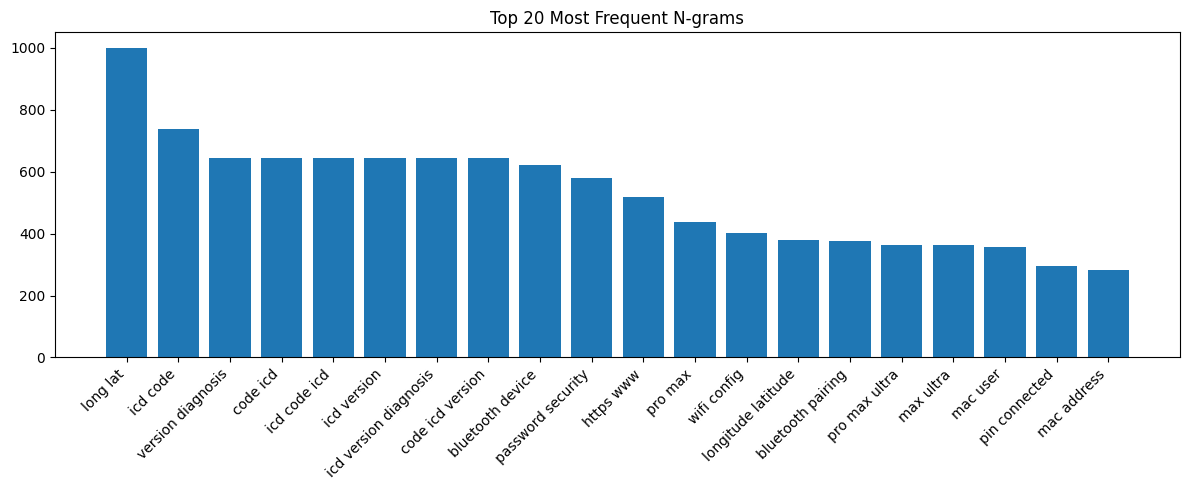

In [79]:
import matplotlib.pyplot as plt

ngram_freq = X_vectorized.sum(axis=0).A1
ngram_names = count_vectorizer.get_feature_names_out()

top_n = 20
top_idx = ngram_freq.argsort()[::-1][:top_n]

top_ngrams = [(ngram_names[i], ngram_freq[i]) for i in top_idx]
print(top_ngrams)

plt.figure(figsize=(12, 5))
plt.bar(ngram_names[top_idx], ngram_freq[top_idx])
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent N-grams')
plt.tight_layout()
plt.show()

In [80]:



clf_pipeline_cv = Pipeline([
    ("count_vectorizer", count_vectorizer),
    ("clf", DecisionTreeClassifier(random_state=38))
])

clf_pipeline_cv.fit(X_train, y_train)

y_pred_cv = clf_pipeline_cv.predict(X_test)
print(classification_report(y_test, y_pred_cv))

dt_f1_macro = f1_score(y_test, y_pred_cv, average='macro')
dt_accuracy = accuracy_score(y_test, y_pred_cv)
print(f"Decision Tree Macro F1-score: {dt_f1_macro:.6f}")
print(f"Decision Tree Accuracy: {dt_accuracy:.6f}")

              precision    recall  f1-score   support

        High       0.97      0.98      0.98       975
         Low       0.98      0.97      0.97       827

    accuracy                           0.98      1802
   macro avg       0.98      0.98      0.98      1802
weighted avg       0.98      0.98      0.98      1802

Decision Tree Macro F1-score: 0.975950
Decision Tree Accuracy: 0.976138


In [81]:
import os

graphviz_paths = [
    r"C:\Program Files\Graphviz\bin",
    r"C:\Program Files (x86)\Graphviz\bin",
]

for p in graphviz_paths:
    if os.path.isdir(p) and p not in os.environ.get("PATH", ""):
        os.environ["PATH"] += os.pathsep + p
        print(f"Added to PATH: {p}")


In [82]:

from sklearn.tree import export_graphviz
import graphviz
from datetime import datetime

tree_model  = clf_pipeline_cv.named_steps["clf"]
vectorizer  = clf_pipeline_cv.named_steps["count_vectorizer"]

dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=vectorizer.get_feature_names_out(),
    class_names=tree_model.classes_.astype(str),
    filled=True,
    rounded=True,
    special_characters=True,
)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"decision_tree_untuned"

graph = graphviz.Source(dot_data)
graph.render(filename, format="pdf", view=True)
print(f"Exported: {filename}.pdf")


Exported: decision_tree_untuned.pdf


In [83]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.decomposition import TruncatedSVD


clf_pipeline_knn = Pipeline([
    ("count_vectorizer", count_vectorizer),
    ("svd", TruncatedSVD(n_components=10, random_state=42)),
    ("clf", KNeighborsClassifier(n_neighbors=10))
])

clf_pipeline_knn.fit(X_train, y_train)
y_pred_knn = clf_pipeline_knn.predict(X_test)
print("=== K-Nearest Neighbors ===")
print(classification_report(y_test, y_pred_knn))

# Calculate and print F1-score and accuracy for KNN
knn_f1_macro = f1_score(y_test, y_pred_knn, average='macro')
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Macro F1-score: {knn_f1_macro:.6f}")
print(f"KNN Accuracy: {knn_accuracy:.6f}")

=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

        High       0.96      0.99      0.97       975
         Low       0.98      0.95      0.97       827

    accuracy                           0.97      1802
   macro avg       0.97      0.97      0.97      1802
weighted avg       0.97      0.97      0.97      1802

KNN Macro F1-score: 0.968617
KNN Accuracy: 0.968923


In [84]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score, accuracy_score

clf_pipeline_nb = Pipeline([
    ("count_vectorizer", count_vectorizer),
    ("clf", MultinomialNB())
])

clf_pipeline_nb.fit(X_train, y_train)
y_pred_nb = clf_pipeline_nb.predict(X_test)
print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb))

# Calculate and print F1-score and accuracy for Naive Bayes
nb_f1_macro = f1_score(y_test, y_pred_nb, average='macro')
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Macro F1-score: {nb_f1_macro:.6f}")
print(f"Naive Bayes Accuracy: {nb_accuracy:.6f}")

=== Naive Bayes ===
              precision    recall  f1-score   support

        High       0.98      0.99      0.98       975
         Low       0.98      0.98      0.98       827

    accuracy                           0.98      1802
   macro avg       0.98      0.98      0.98      1802
weighted avg       0.98      0.98      0.98      1802

Naive Bayes Macro F1-score: 0.981554
Naive Bayes Accuracy: 0.981687


In [85]:
from sklearn.model_selection import GridSearchCV
from datetime import datetime


param_grid_dt = {
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__max_depth": [17,18,19,20],
    "clf__min_samples_split": [2,3,4],
    "clf__min_samples_leaf": [2,3,4],
    "count_vectorizer__ngram_range": [(1, 2), (2, 3), (3,4), (4,5)],
    "count_vectorizer__max_features": [1750,2000,2250]
}

grid_search = GridSearchCV(
    clf_pipeline_cv,
    param_grid=param_grid_dt,
    cv=8,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score: ", grid_search.best_score_)
print("\nClassification Report for the best model:")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nAccuracy: {accuracy}")

with open("TuningLogs.txt", "a") as f:
    f.write("===== DT Grid Search Results =====\n")
    f.write(f"Time: {datetime.now()}\n")
    f.write(f"Grid: {param_grid_dt}\n")
    f.write(f"Best Params: {grid_search.best_params_}\n")
    f.write(f"Best Score: {grid_search.best_score_}\n\n")


Best parameters found:  {'clf__criterion': 'entropy', 'clf__max_depth': 19, 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 2, 'count_vectorizer__max_features': 2000, 'count_vectorizer__ngram_range': (1, 2)}
Best F1 score:  0.9921657860600873

Classification Report for the best model:
              precision    recall  f1-score   support

        High       0.99      1.00      0.99       975
         Low       1.00      0.99      0.99       827

    accuracy                           0.99      1802
   macro avg       0.99      0.99      0.99      1802
weighted avg       0.99      0.99      0.99      1802


Accuracy: 0.9922308546059934


In [86]:
import pandas as pd

# Extract the fitted CountVectorizer from the best pipeline
vectorizer = best_model.named_steps['count_vectorizer']

# Get all ngrams (vocabulary)
ngram_list = vectorizer.get_feature_names_out()
print(f"Total ngrams: {len(ngram_list)}")
print("\nSample ngrams:", ngram_list[:20])

# Get most frequent ngrams using the sum of their counts across training data
X_train_transformed = vectorizer.transform(X_train)
ngram_counts = X_train_transformed.sum(axis=0).A1  # flatten to 1D array

# Create a DataFrame and sort by frequency
ngram_freq_df = pd.DataFrame({
    'ngram': ngram_list,
    'frequency': ngram_counts
}).sort_values('frequency', ascending=False)

print("\nTop 20 most frequent ngrams:")
print(ngram_freq_df.head(20).to_string(index=False))

Total ngrams: 2000

Sample ngrams: ['@' '@ @' '@ cia' '@ dea' '@ dhs' '@ dia' '@ dot' '@ fbi' '@ med' '@ nro'
 '@ nsa' '@ odni' '@ security' '@ state' '@ usaf' '@ usss' '@ va'
 '@ whitehouse' 'abbott' 'abbott freestyle']

Top 20 most frequent ngrams:
    ngram  frequency
     http       1487
 security       1186
bluetooth       1183
      icd       1126
    cfips       1121
 password       1003
      com        975
      mac        950
diagnosis        899
      gov        875
     long        811
      lat        805
 long lat        805
        @        804
     ssid        754
       id        661
  patient        654
     code        612
      pro        607
 icd code        600


[('http', 1487), ('security', 1186), ('bluetooth', 1183), ('icd', 1126), ('cfips', 1121), ('password', 1003), ('com', 975), ('mac', 950), ('diagnosis', 899), ('gov', 875), ('long', 811), ('long lat', 805), ('lat', 805), ('@', 804), ('ssid', 754), ('id', 661), ('patient', 654), ('code', 612), ('pro', 607), ('icd code', 600)]


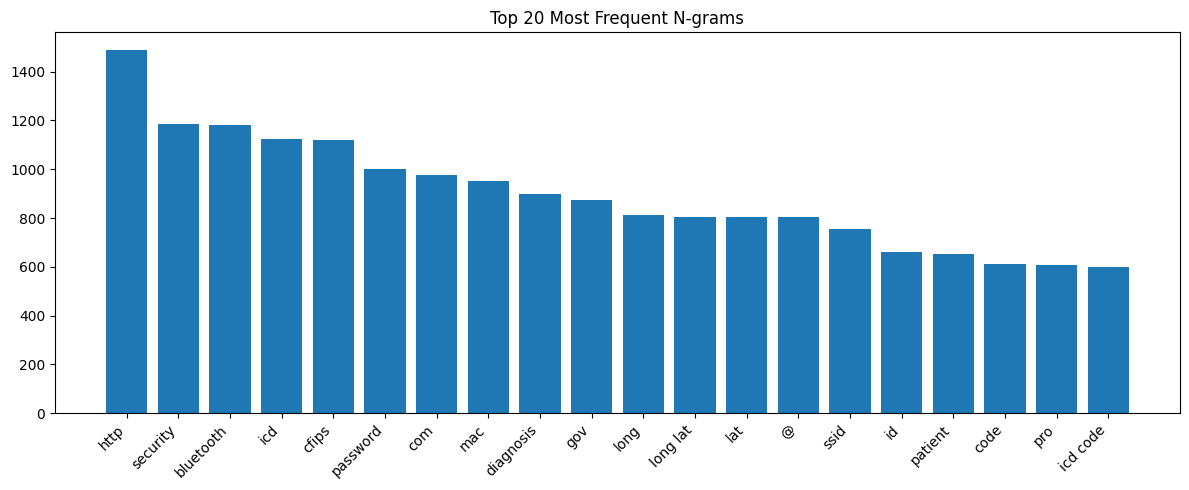

In [87]:

ngram_freq = X_train_transformed.sum(axis=0).A1
ngram_names = vectorizer.get_feature_names_out()

top_n = 20
top_idx = ngram_freq.argsort()[::-1][:top_n]

top_ngrams = [(ngram_names[i], ngram_freq[i]) for i in top_idx]
print(top_ngrams)

plt.figure(figsize=(12, 5))
plt.bar(ngram_names[top_idx], ngram_freq[top_idx])
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent N-grams')
plt.tight_layout()
plt.show()

In [88]:
param_grid_knn = {
    "svd__n_components": [10,13,15],  # all must be < 53
    "clf__n_neighbors": [7,8,9,10],
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["euclidean", "manhattan"],
    "count_vectorizer__ngram_range": [(1,2), (2,3), (3,4)],
    "count_vectorizer__max_features": [1750,2000,2250]

}

grid_knn = GridSearchCV(
    clf_pipeline_knn,
    param_grid=param_grid_knn,
    cv=8,
    scoring="f1_macro",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)
best_model = grid_knn.best_estimator_
print("Best KNN params:", grid_knn.best_params_)
print("Best CV F1 Score:", grid_knn.best_score_)
print("\nClassification Report for the best model:")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nAccuracy: {accuracy}")

with open("TuningLogs.txt", "a") as f:
    f.write("===== KNN Grid Search Results =====\n")
    f.write(f"Grid: {param_grid_knn}\n")
    f.write(f"Best Params: {grid_knn.best_params_}\n")
    f.write(f"Best Score: {grid_knn.best_score_}\n\n")



Best KNN params: {'clf__metric': 'euclidean', 'clf__n_neighbors': 9, 'clf__weights': 'distance', 'count_vectorizer__max_features': 1750, 'count_vectorizer__ngram_range': (1, 2), 'svd__n_components': 15}
Best CV F1 Score: 0.9895188160424425

Classification Report for the best model:
              precision    recall  f1-score   support

        High       0.99      0.99      0.99       975
         Low       0.99      0.98      0.99       827

    accuracy                           0.99      1802
   macro avg       0.99      0.99      0.99      1802
weighted avg       0.99      0.99      0.99      1802


Accuracy: 0.9900110987791343


In [89]:
param_grid_nb = {
    "clf__alpha": [0.2,0.1,0.09],
    "clf__fit_prior": [True, False],
    "clf__force_alpha": [True, False],
    "count_vectorizer__ngram_range": [(1, 2), (2, 3), (3, 4)],
    "count_vectorizer__max_features": [1750,2000,2250]


}

grid_nb = GridSearchCV(
    clf_pipeline_nb,
    param_grid=param_grid_nb,
    cv=8,
    scoring="f1_macro",
    n_jobs=-1
)

grid_nb.fit(X_train, y_train)
best_model = grid_nb.best_estimator_

print("Best Naive Bayes params:", grid_nb.best_params_)
print("Best CV accuracy:", grid_nb.best_score_)
print("\nClassification Report for the best model:")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nAccuracy: {accuracy}")

with open("TuningLogs.txt", "a") as f:
    f.write("===== NB Grid Search Results =====\n")
    f.write(f"Grid: {param_grid_nb}\n")

    f.write(f"Best Params: {grid_nb.best_params_}\n")
    f.write(f"Best Score: {grid_nb.best_score_}\n\n")



Best Naive Bayes params: {'clf__alpha': 0.2, 'clf__fit_prior': False, 'clf__force_alpha': True, 'count_vectorizer__max_features': 2250, 'count_vectorizer__ngram_range': (1, 2)}
Best CV accuracy: 0.9892309461208022

Classification Report for the best model:
              precision    recall  f1-score   support

        High       0.99      1.00      0.99       975
         Low       1.00      0.99      0.99       827

    accuracy                           0.99      1802
   macro avg       0.99      0.99      0.99      1802
weighted avg       0.99      0.99      0.99      1802


Accuracy: 0.9916759156492786


In [90]:
from sklearn.tree import export_graphviz
import graphviz

tree_model  = grid_search.best_estimator_.named_steps["clf"]
vectorizer  = grid_search.best_estimator_.named_steps["count_vectorizer"]

dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=vectorizer.get_feature_names_out(),
    class_names=tree_model.classes_.astype(str),
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=19
)

graph = graphviz.Source(dot_data)
graph.render("decision_tree_tuned", format="pdf", view=True)


'decision_tree_tuned.pdf'

In [91]:
import joblib

# The best performing model was the KNN model based on the GridSearchCV results.
best_model_to_export = grid_knn.best_estimator_

# Define the filename for the exported model
model_filename = 'best_knn_model.joblib'

# Export the model
joblib.dump(best_model_to_export, model_filename)

print(f"Best model exported to {model_filename}")

Best model exported to best_knn_model.joblib


In [92]:
model2 = grid_search.best_estimator_

model_filename = 'dt.joblib'

#joblib.dump(model2, model_filename)

#print(f"Best model exported to {model_filename}")

model3 = grid_nb.best_estimator_

model_filename = 'nb.joblib'

#joblib.dump(model3, model_filename)

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd
import time

from gpt4_classification import classify_batch_with_ai
import importlib
import gpt4_classification
importlib.reload(gpt4_classification)
from gpt4_classification import classify_batch_with_ai

print("STARTING SINGLE-RUN EVALUATION WITH TIMING...")

X_full = df['Tag']
y_full = df['Sensitivity']

dt_model = grid_search.best_estimator_
knn_model = grid_knn.best_estimator_
nb_model = grid_nb.best_estimator_

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, train_size=0.8,
    random_state=42, stratify=y_full
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

results = {}

# DT
print("\n--- Decision Tree ---")
dt_model.fit(X_train, y_train)
start = time.time()
y_pred_dt = dt_model.predict(X_test)
dt_time = (time.time() - start) / len(X_test)

results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, y_pred_dt),
    'f1_macro': f1_score(y_test, y_pred_dt, average='macro'),
    'precision': precision_score(y_test, y_pred_dt, average='macro'),
    'recall': recall_score(y_test, y_pred_dt, average='macro'),
    'avg_time_per_entry_s': dt_time
}

# KNN
print("--- KNN ---")
knn_model.fit(X_train, y_train)
start = time.time()
y_pred_knn = knn_model.predict(X_test)
knn_time = (time.time() - start) / len(X_test)

results['KNN'] = {
    'accuracy': accuracy_score(y_test, y_pred_knn),
    'f1_macro': f1_score(y_test, y_pred_knn, average='macro'),
    'precision': precision_score(y_test, y_pred_knn, average='macro'),
    'recall': recall_score(y_test, y_pred_knn, average='macro'),
    'avg_time_per_entry_s': knn_time
}

# NB
print("--- Naive Bayes ---")
nb_model.fit(X_train, y_train)
start = time.time()
y_pred_nb = nb_model.predict(X_test)
nb_time = (time.time() - start) / len(X_test)

results['Naive Bayes'] = {
    'accuracy': accuracy_score(y_test, y_pred_nb),
    'f1_macro': f1_score(y_test, y_pred_nb, average='macro'),
    'precision': precision_score(y_test, y_pred_nb, average='macro'),
    'recall': recall_score(y_test, y_pred_nb, average='macro'),
    'avg_time_per_entry_s': nb_time
}

# GPT
print("--- AI Model (Batch Processing) ---")
X_test_list = X_test.tolist()
BATCH_SIZE = 20
ai_preds = []

#start = time.time()
#for i in range(0, len(X_test_list), BATCH_SIZE):
#    batch_texts = X_test_list[i:i+BATCH_SIZE]
#    print(f"Processing AI batch {i // BATCH_SIZE + 1}...", end='\r')
#    batch_p, _, _ = classify_batch_with_ai(batch_texts)
#    ai_preds.extend(batch_p)
#ai_time = (time.time() - start) / len(X_test_list)

print("AI Classification complete.             ")

#results['AI Model'] = {
#    'accuracy': accuracy_score(y_test, ai_preds),
#    'f1_macro': f1_score(y_test, ai_preds, average='macro'),
#    'precision': precision_score(y_test, ai_preds, average='macro'),
#    'recall': recall_score(y_test, ai_preds, average='macro'),
#  'avg_time_per_entry_s': ai_time
#}


print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

summary_df = pd.DataFrame([
    {
        'Model': model,
        'Accuracy': f"{v['accuracy']:.4f}",
        'F1-Score': f"{v['f1_macro']:.4f}",
        'Precision': f"{v['precision']:.4f}",
        'Recall': f"{v['recall']:.4f}",
        'Avg Time/Entry (s)': f"{v['avg_time_per_entry_s']:.6f}"
    }
    for model, v in results.items()
])

print(summary_df.to_string(index=False))

best_model = max(results, key=lambda x: results[x]['f1_macro'])
print(f"\n🏆 Best Model (by F1-score): {best_model}")

STARTING SINGLE-RUN EVALUATION WITH TIMING...
Train size: 7204, Test size: 1802

--- Decision Tree ---
--- KNN ---
--- Naive Bayes ---
--- AI Model (Batch Processing) ---
AI Classification complete.             

RESULTS SUMMARY
        Model Accuracy F1-Score Precision Recall Avg Time/Entry (s)
Decision Tree   0.9922   0.9922    0.9927 0.9917           0.000030
          KNN   0.9900   0.9899    0.9903 0.9896           0.000033
  Naive Bayes   0.9917   0.9916    0.9920 0.9913           0.000024

🏆 Best Model (by F1-score): Decision Tree


In [94]:
# ==========================================
# FINAL EVALUATION CELL
# Includes Decision Tree, KNN, Naive Bayes, AND AI MODEL
# ==========================================

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import precision_score, recall_score
import numpy as np
import pandas as pd
import time

# --- AI IMPORT ---
from gpt4_classification import classify_batch_with_ai

import importlib
import gpt4_classification
importlib.reload(gpt4_classification)
from gpt4_classification import classify_batch_with_ai

print("STARTING COMPREHENSIVE EVALUATION (INCLUDING AI MODEL)...")

X_full = df['Tag']
y_full = df['Sensitivity']

dt_model = grid_search.best_estimator_
knn_model = grid_knn.best_estimator_
nb_model = grid_nb.best_estimator_

print("=" * 70)
print("3-Fold Cross-Validation with Different Train-Test Splits")
print("Using the FULL dataset with 3 different 80-20 splits")
print("=" * 70)

sss = StratifiedShuffleSplit(
    n_splits=3,        # run 3 times
    test_size=0.2,     # 20% test
    train_size=0.8,    # 80% train
    random_state=42
)

# Initialize results dictionary including AI Model
results = {
    'Decision Tree': {'accuracy': [], 'f1_macro': [], 'precision': [], 'recall': []},
    'KNN': {'accuracy': [], 'f1_macro': [], 'precision': [], 'recall': []},
    'Naive Bayes': {'accuracy': [], 'f1_macro': [], 'precision': [], 'recall': []},
    'AI Model': {'accuracy': [], 'f1_macro': [], 'precision': [], 'recall': []}
}

for fold_num, (train_idx, test_idx) in enumerate(sss.split(X_full, y_full), 1):
    print(f"\n{'='*70}")
    print(f"SPLIT {fold_num} - Training on {len(train_idx)} samples, Testing on {len(test_idx)} samples")
    print(f"{'='*70}")
    
    X_train_fold = X_full.iloc[train_idx]
    X_test_fold = X_full.iloc[test_idx]
    y_train_fold = y_full.iloc[train_idx]
    y_test_fold = y_full.iloc[test_idx]

    print("Shape of X_train:", X_train_fold.shape)
    print("Shape of X_test:", X_test_fold.shape)
    print("Shape of y_train:", y_train_fold.shape)
    print("Shape of y_test:", y_test_fold.shape)
    
    print("\n--- Decision Tree ---")
    dt_model.fit(X_train_fold, y_train_fold)
    y_pred_dt = dt_model.predict(X_test_fold)
    dt_acc = accuracy_score(y_test_fold, y_pred_dt)
    dt_f1 = f1_score(y_test_fold, y_pred_dt, average='macro')
    dt_precision = precision_score(y_test_fold, y_pred_dt, average='macro')
    dt_recall = recall_score(y_test_fold, y_pred_dt, average='macro')
    
    results['Decision Tree']['accuracy'].append(dt_acc)
    results['Decision Tree']['f1_macro'].append(dt_f1)
    results['Decision Tree']['precision'].append(dt_precision)
    results['Decision Tree']['recall'].append(dt_recall)
    
    print(f"Accuracy: {dt_acc:.4f}, F1: {dt_f1:.4f}, Precision: {dt_precision:.4f}, Recall: {dt_recall:.4f}")
    
    print("\n--- K-Nearest Neighbors ---")
    knn_model.fit(X_train_fold, y_train_fold)
    y_pred_knn = knn_model.predict(X_test_fold)
    knn_acc = accuracy_score(y_test_fold, y_pred_knn)
    knn_f1 = f1_score(y_test_fold, y_pred_knn, average='macro')
    knn_precision = precision_score(y_test_fold, y_pred_knn, average='macro')
    knn_recall = recall_score(y_test_fold, y_pred_knn, average='macro')
    
    results['KNN']['accuracy'].append(knn_acc)
    results['KNN']['f1_macro'].append(knn_f1)
    results['KNN']['precision'].append(knn_precision)
    results['KNN']['recall'].append(knn_recall)
    
    print(f"Accuracy: {knn_acc:.4f}, F1: {knn_f1:.4f}, Precision: {knn_precision:.4f}, Recall: {knn_recall:.4f}")
    
    print("\n--- Naive Bayes ---")
    nb_model.fit(X_train_fold, y_train_fold)
    y_pred_nb = nb_model.predict(X_test_fold)
    nb_acc = accuracy_score(y_test_fold, y_pred_nb)
    nb_f1 = f1_score(y_test_fold, y_pred_nb, average='macro')
    nb_precision = precision_score(y_test_fold, y_pred_nb, average='macro')
    nb_recall = recall_score(y_test_fold, y_pred_nb, average='macro')
    
    results['Naive Bayes']['accuracy'].append(nb_acc)
    results['Naive Bayes']['f1_macro'].append(nb_f1)
    results['Naive Bayes']['precision'].append(nb_precision)
    results['Naive Bayes']['recall'].append(nb_recall)
    
    print(f"Accuracy: {nb_acc:.4f}, F1: {nb_f1:.4f}, Precision: {nb_precision:.4f}, Recall: {nb_recall:.4f}")

    # --- AI Model Integration ---
    print("\n--- AI Model (Batch Processing) ---")
    # We need to process the fold in batches to respect the token limits/design
    ai_preds = []
    
    # Convert series to list for batching
    X_test_list = X_test_fold.tolist()
    
    BATCH_SIZE = 20
    total_ai = len(X_test_list)
    
   # for i in range(0, total_ai, BATCH_SIZE):
   #     batch_texts = X_test_list[i:i+BATCH_SIZE]
   #     print(f"Processing AI batch {i // BATCH_SIZE + 1}...", end='\r')
   #     # CALLING THE IMPORTED FUNCTION
   #     batch_p, _, _ = classify_batch_with_ai(batch_texts)
   #     ai_preds.extend(batch_p)
    
    print("AI Classification complete.             ")
    
    # Calculate metrics for AI
    ai_acc = 0 # accuracy_score(y_test_fold, ai_preds)
    ai_f1 = 0 #f1_score(y_test_fold, ai_preds, average='macro')
    ai_precision =0 # precision_score(y_test_fold, ai_preds, average='macro')
    ai_recall = 0 #recall_score(y_test_fold, ai_preds, average='macro')
    
    results['AI Model']['accuracy'].append(ai_acc)
    results['AI Model']['f1_macro'].append(ai_f1)
    results['AI Model']['precision'].append(ai_precision)
    results['AI Model']['recall'].append(ai_recall)
    
    print(f"Accuracy: {ai_acc:.4f}, F1: {ai_f1:.4f}, Precision: {ai_precision:.4f}, Recall: {ai_recall:.4f}")

    
    print(f"\n--- Split {fold_num} Summary ---")
    split_comparison = pd.DataFrame({
        'Model': ['Decision Tree', 'KNN', 'Naive Bayes', 'AI Model'],
        'Accuracy': [dt_acc, knn_acc, nb_acc, ai_acc],
        'F1-Score': [dt_f1, knn_f1, nb_f1, ai_f1],
        'Precision': [dt_precision, knn_precision, nb_precision, ai_precision],
        'Recall': [dt_recall, knn_recall, nb_recall, ai_recall]
    })
    print(split_comparison.to_string(index=False))
    best_model = split_comparison.loc[split_comparison['Accuracy'].idxmax(), 'Model']
    print(f"\nBest model for Split {fold_num}: {best_model}")


print("\n" + "=" * 70)
print("COMPREHENSIVE SUMMARY - All Train-Test Splits")
print("=" * 70)

# Per-split comparison table
summary_data = []
for fold_num in range(1, 4):
    summary_data.append({
        'Split': fold_num,
        'DT_Acc': f"{results['Decision Tree']['accuracy'][fold_num-1]:.4f}",
        'DT_F1': f"{results['Decision Tree']['f1_macro'][fold_num-1]:.4f}",
        'KNN_Acc': f"{results['KNN']['accuracy'][fold_num-1]:.4f}",
        'KNN_F1': f"{results['KNN']['f1_macro'][fold_num-1]:.4f}",
        'NB_Acc': f"{results['Naive Bayes']['accuracy'][fold_num-1]:.4f}",
        'NB_F1': f"{results['Naive Bayes']['f1_macro'][fold_num-1]:.4f}",
        'AI_Acc': f"{results['AI Model']['accuracy'][fold_num-1]:.4f}",
        'AI_F1': f"{results['AI Model']['f1_macro'][fold_num-1]:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\nPer-Split Performance:")
print(summary_df.to_string(index=False))

print("\n" + "=" * 70)
print("OVERALL STATISTICS (Mean ± Std)")
print("=" * 70)

stats_data = []
for model_name in ['Decision Tree', 'KNN', 'Naive Bayes', 'AI Model']:
    acc_mean = np.mean(results[model_name]['accuracy'])
    acc_std = np.std(results[model_name]['accuracy'])
    f1_mean = np.mean(results[model_name]['f1_macro'])
    f1_std = np.std(results[model_name]['f1_macro'])
    prec_mean = np.mean(results[model_name]['precision'])
    prec_std = np.std(results[model_name]['precision'])
    rec_mean = np.mean(results[model_name]['recall'])
    rec_std = np.std(results[model_name]['recall'])
    
    stats_data.append({
        'Model': model_name,
        'Accuracy': f"{acc_mean:.4f} ± {acc_std:.4f}",
        'F1-Score': f"{f1_mean:.4f} ± {f1_std:.4f}",
        'Precision': f"{prec_mean:.4f} ± {prec_std:.4f}",
        'Recall': f"{rec_mean:.4f} ± {rec_std:.4f}"
    })

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))

best_overall = max(
    ['Decision Tree', 'KNN', 'Naive Bayes', 'AI Model'],
    key=lambda x: np.mean(results[x]['f1_macro'])
)
print(f"\n🏆 Best Overall Model (by mean F1-score): {best_overall}")

STARTING COMPREHENSIVE EVALUATION (INCLUDING AI MODEL)...
3-Fold Cross-Validation with Different Train-Test Splits
Using the FULL dataset with 3 different 80-20 splits

SPLIT 1 - Training on 7204 samples, Testing on 1802 samples
Shape of X_train: (7204,)
Shape of X_test: (1802,)
Shape of y_train: (7204,)
Shape of y_test: (1802,)

--- Decision Tree ---
Accuracy: 0.9922, F1: 0.9922, Precision: 0.9927, Recall: 0.9917

--- K-Nearest Neighbors ---
Accuracy: 0.9900, F1: 0.9899, Precision: 0.9903, Recall: 0.9896

--- Naive Bayes ---
Accuracy: 0.9917, F1: 0.9916, Precision: 0.9920, Recall: 0.9913

--- AI Model (Batch Processing) ---
AI Classification complete.             
Accuracy: 0.0000, F1: 0.0000, Precision: 0.0000, Recall: 0.0000

--- Split 1 Summary ---
        Model  Accuracy  F1-Score  Precision   Recall
Decision Tree  0.992231  0.992171   0.992685 0.991719
          KNN  0.990011  0.989936   0.990335 0.989576
  Naive Bayes  0.991676  0.991614   0.991960 0.991298
     AI Model  0.0000

In [95]:

print("\n" + "="*70)
print("MODEL COMPARISON & IMPROVEMENT ANALYSIS")
print("="*70)

# 1. Calculate Mean Metrics for each model
mean_metrics = {}
for model in results:
    mean_metrics[model] = {
        'Accuracy': np.mean(results[model]['accuracy']),
        'F1-Score': np.mean(results[model]['f1_macro']),
        'Precision': np.mean(results[model]['precision']),
        'Recall': np.mean(results[model]['recall'])
    }

metrics_df = pd.DataFrame(mean_metrics).T
print("\n--- Average Performance Metrics ---")
print(metrics_df)

# 2. Identify the Baseline Model (e.g., Decision Tree or the worst performer)
# Or compares Best Model vs Others.
# Let's compare "Best Overall" (already identified) vs others.

best_model_name = best_overall # From previous cell
print(f"\nComparing all models against the Best Performer: {best_model_name}")

improvement_data = []

exclude_models = [best_model_name]
baseline_metrics = mean_metrics[best_model_name]

for model in mean_metrics:
    if model == best_model_name:
        continue
    
    row = {'Model': model}
    for metric in ['Accuracy', 'F1-Score', 'Precision', 'Recall']:
        # Improvement: (Best - Other) / Other * 100
        # If Best is higher, it's positive improvement. 
        # If Other is 0 (unlikely but possible for broken models), handle it.
        
        other_val = mean_metrics[model][metric]
        best_val = baseline_metrics[metric]
        
        if other_val == 0:
            imp = float('inf')
        else:
            imp = ((best_val - other_val) / other_val) * 100
            
        row[f'{metric} Improvement (%)'] = f"{imp:+.2f}%"
        
    improvement_data.append(row)

imp_df = pd.DataFrame(improvement_data)
print(f"\n--- Improvement of {best_model_name} over other models ---")
print(imp_df.to_string(index=False))

# 3. Pairwise Matrix (Optional but detailed)
# metric = 'F1-Score'
# print(f"\n--- Pairwise {metric} Improvement Matrix (Row vs Column) ---")
# matrix_data = {}
# for row_model in mean_metrics:
#     matrix_data[row_model] = {}
#     for col_model in mean_metrics:
#         val_row = mean_metrics[row_model][metric]
#         val_col = mean_metrics[col_model][metric]
#         if val_col == 0:
#              perc = np.nan
#         else:
#              perc = ((val_row - val_col) / val_col) * 100
#         matrix_data[row_model][col_model] = f"{perc:+.2f}%"

# print(pd.DataFrame(matrix_data))



MODEL COMPARISON & IMPROVEMENT ANALYSIS

--- Average Performance Metrics ---
               Accuracy  F1-Score  Precision    Recall
Decision Tree  0.990566  0.990490   0.991104  0.989997
KNN            0.989641  0.989572   0.989545  0.989632
Naive Bayes    0.990381  0.990310   0.990586  0.990071
AI Model       0.000000  0.000000   0.000000  0.000000

Comparing all models against the Best Performer: Decision Tree

--- Improvement of Decision Tree over other models ---
      Model Accuracy Improvement (%) F1-Score Improvement (%) Precision Improvement (%) Recall Improvement (%)
        KNN                   +0.09%                   +0.09%                    +0.16%                 +0.04%
Naive Bayes                   +0.02%                   +0.02%                    +0.05%                 -0.01%
   AI Model                    +inf%                    +inf%                     +inf%                  +inf%
